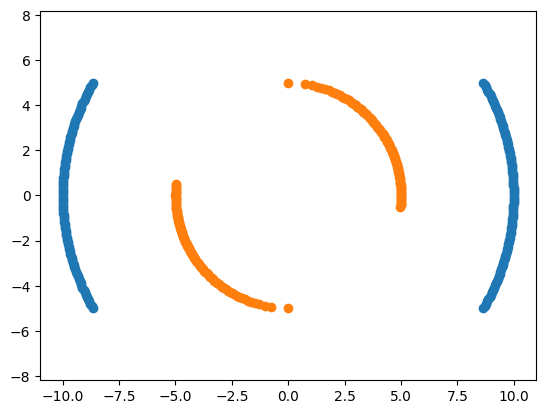

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

x1 = np.linspace(-0.5, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

plt.scatter(y, x)
plt.scatter(y1, x1)

plt.axis('equal')   # important
plt.show()

In [3]:
import pandas as pd 

df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['x1','x2'])
df1['y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['x1','x2'])
df2['y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,x1,x2,y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [4]:
df.tail()

,x1,x2,y
395,-1.474055,-4.777778,1
396,-1.280191,-4.833333,1
397,-1.048220,-4.888889,1
398,-0.743283,-4.944444,1
399,-0.000000,-5.000000,1


In [5]:
x = df.iloc[:,:2]
y=df.y

In [6]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: y, Length: 400, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [8]:
y_train

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: y, Length: 300, dtype: int64

## polynomial kernal [ K(x,y)=(x^y+c)^d ] 

In [9]:
### we need to find component for the pollynomical kernel
#X1,X2,X1_square,x2_square,x1*x2
df['x1_square'] = df['x1']**2
df['x2_square'] = df['x2']**2
df['x1*x2'] = (df['x1']*df['x2'])
df.head()

,x1,x2,y,x1_square,x2_square,x1*x2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [10]:
x = df[['x1','x2','x1_square','x2_square','x1*x2']]
y = df['y']

In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: y, Length: 400, dtype: int64

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [13]:
x_train

,x1,x2,x1_square,x2_square,x1*x2
247,4.532462,2.111111,20.543210,4.456790,9.568530
110,-9.169553,3.989899,84.080706,15.919294,-36.585591
16,9.410082,-3.383838,88.549638,11.450362,-31.842196
66,9.860133,1.666667,97.222222,2.777778,16.433555
153,-9.993749,-0.353535,99.875013,0.124987,3.533143
...,...,...,...,...,...
71,9.761334,2.171717,95.283645,4.716355,21.198857
106,-8.982945,4.393939,80.693297,19.306703,-39.470515
270,3.676334,3.388889,13.515432,11.484568,12.458688
348,-4.506169,-2.166667,20.305556,4.694444,9.763365


In [14]:
import plotly.express as px

fig = px.scatter_3d(df, x='x1', y='x2', z='x1*x2', color='y')
fig.show(renderer='browser')

In [15]:
fig = px.scatter_3d(df, x='x1_square', y='x2_square', z='x1*x2', color='y')
fig.show(renderer='browser')